#### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Questions`
> How many employees left the company each month?

> Which department has the highest attrition count?

> Is there a relationship between salary bracket and attrition?

> What is the month-over-month (MoM) percentage change in attrition?

> Which month had the highest and lowest attrition?

In [2]:
# Employee attrition data — 16 records over 6 months
data = {
    'Employee_ID': ['E001','E002','E003','E004','E005','E006','E007','E008',
                    'E009','E010','E011','E012','E013','E014','E015','E016'],

    'Department': ['Engineering','Sales','HR','Engineering','Sales',
                   'Engineering','HR','Sales','Engineering','HR',
                   'Sales','Engineering','Sales','HR','Engineering','Sales'],

    'Salary_Bracket': ['High','Low','Medium','Medium','Low',
                       'High','Low','Medium','Medium','High',
                       'Low','High','Medium','Low','Medium','High'],

    'Left_Company': [1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0],

    'Month': ['2024-01', '2024-01', '2024-01', '2024-02', '2024-02',
              '2024-02', '2024-03', '2024-03', '2024-03', '2024-04',
              '2024-04', '2024-04', '2024-05', '2024-05', '2024-05',
              '2024-06']
}

#### `Step 1 :- Load and Explore Data`

In [3]:
# Create DataFrame with employee attrition records
data_frame = pd.DataFrame(data)

data_frame['Month'] = pd.to_datetime(data_frame['Month'])

data_frame

,Employee_ID,Department,Salary_Bracket,Left_Company,Month
0,E001,Engineering,High,1,2024-01-01
1,E002,Sales,Low,1,2024-01-01
2,E003,HR,Medium,0,2024-01-01
3,E004,Engineering,Medium,1,2024-02-01
4,E005,Sales,Low,1,2024-02-01
5,E006,Engineering,High,0,2024-02-01
6,E007,HR,Low,1,2024-03-01
7,E008,Sales,Medium,0,2024-03-01
8,E009,Engineering,Medium,1,2024-03-01
9,E010,HR,High,0,2024-04-01


#### `Step 2 :- Monthly Attrition Count`

In [4]:
# Convert Month into monthly period for grouping
data_frame['Month_Period'] = data_frame['Month'].dt.to_period('M')

data_frame

,Employee_ID,Department,Salary_Bracket,Left_Company,Month,Month_Period
0,E001,Engineering,High,1,2024-01-01,2024-01
1,E002,Sales,Low,1,2024-01-01,2024-01
2,E003,HR,Medium,0,2024-01-01,2024-01
3,E004,Engineering,Medium,1,2024-02-01,2024-02
4,E005,Sales,Low,1,2024-02-01,2024-02
5,E006,Engineering,High,0,2024-02-01,2024-02
6,E007,HR,Low,1,2024-03-01,2024-03
7,E008,Sales,Medium,0,2024-03-01,2024-03
8,E009,Engineering,Medium,1,2024-03-01,2024-03
9,E010,HR,High,0,2024-04-01,2024-04


In [5]:
# Count employees who left, grouped by month
monthly_attrition = data_frame[data_frame['Left_Company'] == 1].groupby('Month_Period')['Left_Company'].sum()

monthly_attrition

Month_Period
2024-01    2
2024-02    2
2024-03    2
2024-04    1
2024-05    3
Freq: M, Name: Left_Company, dtype: int64

#### `Step 3 :- Department-wise Attrition`

In [6]:
# Count attrition per department
department_attrition = data_frame[data_frame['Left_Company'] == 1].groupby('Department')['Left_Company'].sum()

department_attrition

Department
Engineering    4
HR             2
Sales          4
Name: Left_Company, dtype: int64

#### `Step 4 :- Salary Bracket vs Attrition`

In [7]:
# Count attrition per salary bracket
salary_attrition = data_frame[data_frame['Left_Company'] == 1].groupby('Salary_Bracket')['Left_Company'].sum()

salary_attrition

Salary_Bracket
High      1
Low       5
Medium    4
Name: Left_Company, dtype: int64

#### `Step 5 :- Month-over-Month % Change`

In [8]:
# Calculate percentage change in attrition month to month
month_over_month_change = (monthly_attrition.pct_change() * 100).round(2)

month_over_month_change

Month_Period
2024-01      NaN
2024-02      0.0
2024-03      0.0
2024-04    -50.0
2024-05    200.0
Freq: M, Name: Left_Company, dtype: float64

#### `Step 6 :- Highest and Lowest Attrition Month`

In [9]:
# Identify months with max attrition
highest_month = monthly_attrition.idxmax()

highest_month

Period('2024-05', 'M')

In [10]:
# Identify months with min attrition
lowest_month = monthly_attrition.idxmin()

lowest_month

Period('2024-04', 'M')

#### `Step 7 :- Chart 1 — Monthly Attrition Trend`

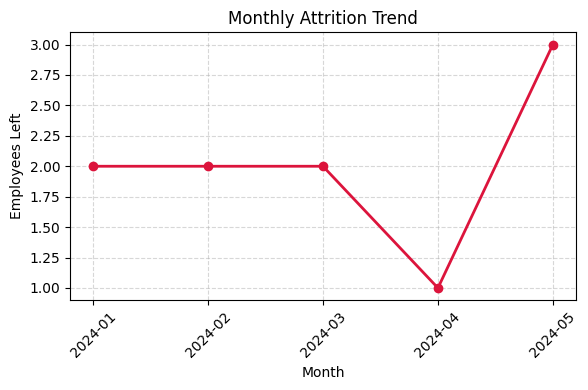

In [11]:
# Line chart showing monthly attrition trend
plt.figure(figsize = (6, 4))

plt.plot(monthly_attrition.index.astype(str), monthly_attrition.values, marker = 'o', color = 'crimson', linewidth = 2)

plt.title('Monthly Attrition Trend')

plt.xlabel('Month')

plt.ylabel('Employees Left')

plt.xticks(rotation = 45)

plt.grid(True, linestyle = '--', alpha = 0.5)

plt.tight_layout()

plt.savefig('4_Insights_Monthly_Attrition_Trend.png')

plt.show()

#### `Step 8 :- Chart 2 — Department-wise Attrition`

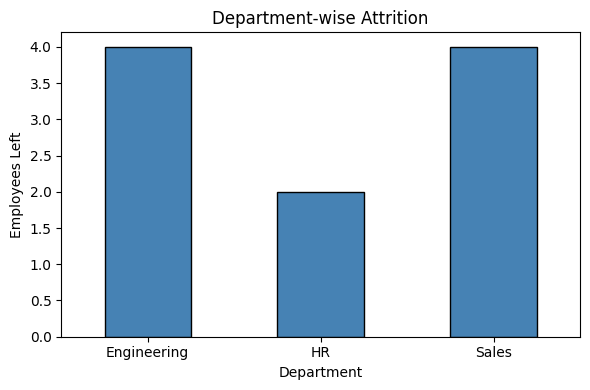

In [12]:
# Bar chart showing attrition per department
plt.figure(figsize = (6, 4))

department_attrition.plot(kind = 'bar', color = 'steelblue', edgecolor = 'black')

plt.title('Department-wise Attrition')

plt.xlabel('Department')

plt.ylabel('Employees Left')

plt.xticks(rotation = 0)

plt.tight_layout()

plt.savefig('4_Insights_Department_Attrition.png')

plt.show()

#### `Step 9 :- Print Outputs`

In [13]:
print(f'\nMonthly Attrition:\n{monthly_attrition}')

print(f'\nDepartment-wise Attrition:\n{department_attrition}')

print(f'\nSalary Bracket vs Attrition:\n{salary_attrition}')

print(f'\nMonth-over-Month % Change:\n{month_over_month_change}')

print(f'\nHighest Attrition Month:\n{highest_month}')

print(f'\nLowest Attrition Month:\n{lowest_month}')


Monthly Attrition:
Month_Period
2024-01    2
2024-02    2
2024-03    2
2024-04    1
2024-05    3
Freq: M, Name: Left_Company, dtype: int64

Department-wise Attrition:
Department
Engineering    4
HR             2
Sales          4
Name: Left_Company, dtype: int64

Salary Bracket vs Attrition:
Salary_Bracket
High      1
Low       5
Medium    4
Name: Left_Company, dtype: int64

Month-over-Month % Change:
Month_Period
2024-01      NaN
2024-02      0.0
2024-03      0.0
2024-04    -50.0
2024-05    200.0
Freq: M, Name: Left_Company, dtype: float64

Highest Attrition Month:
2024-05

Lowest Attrition Month:
2024-04


#### `Information`
> Rows: 16

> Columns: 6 (Employee_ID, Department, Salary_Bracket, Left_Company, Month, Month_Period)

> No missing values

#### `Data Insights`
> Attrition trend: Jan=2, Feb=2, Mar=2, Apr=1, May=3

> Sales & Engineering tie for highest attrition (4 each)

> Low salary bracket has highest attrition (5), Medium=4, High=1

> Month over Month change: NaN, 0%, 0%, -50%, +200%

> Highest attrition month: May; Lowest: April

> June has only 1 record → insufficient data to conclude

#### `Business Insights`
> Attrition is steady early in the year but spikes in May — possible seasonal or workload factor.

> Sales and Engineering are equally affected — both need attention.

> Low salary bracket employees are leaving the most — compensation issue.

> June’s “zero attrition” is not meaningful due to sparse data.

#### `Risks`
> High attrition in Sales and Engineering could impact productivity.

> Compensation dissatisfaction may spread to other departments.

> Sudden spikes (May) indicate instability in workforce morale.

#### `Opportunities`
> Investigate May spike — identify root causes.

> Revise salary structure for Low bracket.

> Strengthen retention programs in Sales and Engineering.

#### `Recommendations`
> Conduct exit interviews for May leavers.

> Implement salary benchmarking for Low bracket.

> Provide stress management and training support in Sales & Engineering.

> Quantified impact: Reducing Sales attrition by 50% retains ~2 employees. Assuming average monthly salary of ₹50,000, rehiring cost savings = ₹3,00,000–₹4,50,000 per year.

#### `Expected Business Impact`
> Lower attrition → reduced hiring costs and better team stability.

> Improved compensation → higher employee satisfaction.

> Stronger Sales retention → sustained revenue growth.

#### `Future Prediction`
> If no action is taken, attrition may spike again in Q3.

> Sales and Engineering will remain vulnerable.

> Compensation reforms could reduce attrition in Low bracket.

> June’s sparse data highlights need for continuous monitoring.